# Feature tour: term-based PDE solver

This notebook exercises the refactored `finite_differences` package. A PDE is written as

$$0 = f(u),\qquad u_t = f(u),\qquad\text{or}\qquad u_{tt} = f(u),$$

where the spatial right-hand side $f$ is a **sum of composable terms** — diffusion, advection,
reaction, sources, or arbitrary nonlinear functions — and is solved either directly (steady) or by
the **method of lines** (explicit RK / implicit Euler / Crank–Nicolson).

Covered below:

1. Steady Poisson (2D, manufactured solution)
2. Steady Laplace with per-edge Dirichlet data (`DirichletBox`)
3. Heat equation under three boundary conditions (Dirichlet, insulated Neumann, hot Dirichlet)
4. Periodic advection: upwind vs. central schemes
5. Wave equation (`time_order=2`) standing mode vs. the exact solution
6. Nonlinear Fisher–KPP traveling front (`FunctionTerm`)
7. 2D advection–diffusion
8. Animation helper demo
9. Source-driven heating: `SourceTerm` + 2D animation

In [10]:
# Make the repo root importable no matter where the notebook kernel starts
import sys
from pathlib import Path
_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'finite_differences').is_dir())
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import numpy as np
import matplotlib.pyplot as plt

from finite_differences import (
    Grid, PDE,
    DiffusionTerm, AdvectionTerm, ReactionTerm, SourceTerm, FunctionTerm,
)
from finite_differences.bc import Dirichlet, DirichletBox, Neumann, Periodic
from finite_differences.utils import quick_plot, animated_plot

%matplotlib inline
plt.rcParams["figure.figsize"] = (7, 4.5)

## 1. Steady Poisson (2D)

Solve $\nabla^2 u = -2\pi^2 \sin(\pi x)\sin(\pi y)$ with $u=0$ on the boundary, whose exact
solution is $u = \sin(\pi x)\sin(\pi y)$. Written as the steady problem
$0 = \nabla^2 u + s(x,y)$ using `DiffusionTerm + SourceTerm` and `time_order=0`.

L2 error vs exact: 8.394e-03  (h = 2.041e-02)


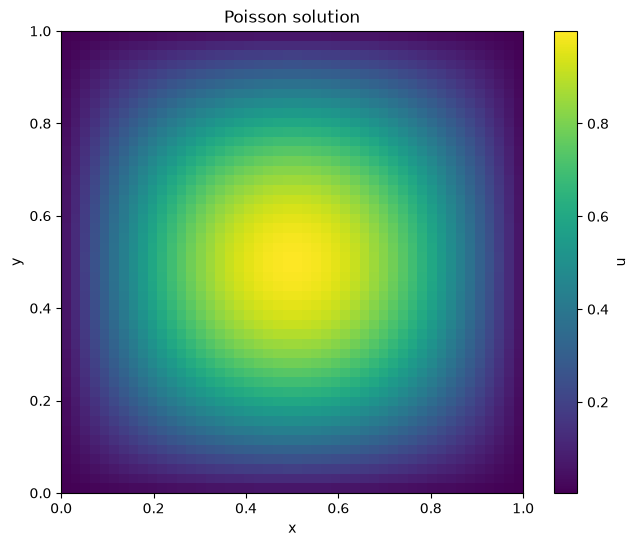

In [11]:
grid = Grid(48, 48, lx=1.0, ly=1.0)
X, Y = grid.mesh()

def source(X, Y):
    return 2.0 * np.pi**2 * np.sin(np.pi * X) * np.sin(np.pi * Y)

pde = PDE(grid, [DiffusionTerm(1.0), SourceTerm(source)], Dirichlet(0.0), time_order=0)
u = pde.solve_steady()

u_exact = np.sin(np.pi * X) * np.sin(np.pi * Y)
print(f"L2 error vs exact: {np.linalg.norm(u - u_exact):.3e}  (h = {grid.dx:.3e})")

fig, ax = quick_plot(u, dimension="2D", title="Poisson solution", xlabel="x", ylabel="y",
                     cbarlabel="u", extent=[0, 1, 0, 1])
plt.show()

## 2. Steady Laplace with per-edge boundary values

`DirichletBox` fixes a different constant on each edge. Here the left edge is held at 1 and the
rest at 0; the interior satisfies the discrete maximum principle (all values within the edge data).

min = 0.0003, max = 0.9670  (maximum principle: within [0, 1])


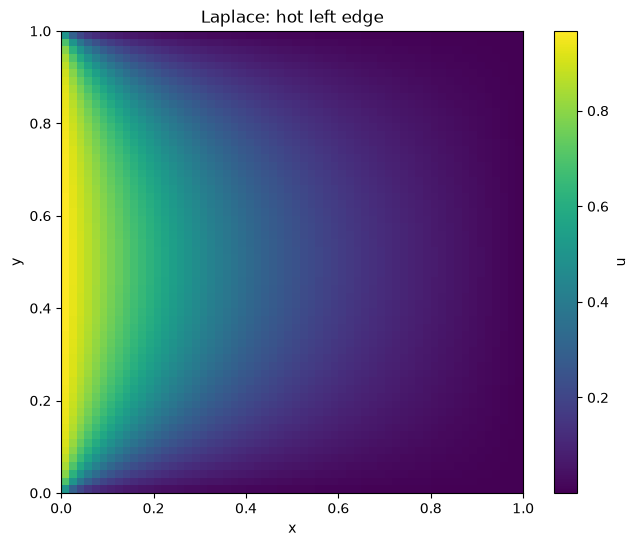

In [12]:
grid = Grid(60, 60, lx=1.0, ly=1.0)
pde = PDE(grid, [DiffusionTerm(1.0)],
          DirichletBox(left=1.0, right=0.0, bottom=0.0, top=0.0), time_order=0)
u = pde.solve_steady()
print(f"min = {u.min():.4f}, max = {u.max():.4f}  (maximum principle: within [0, 1])")

fig, ax = quick_plot(u, dimension="2D", title="Laplace: hot left edge", xlabel="x", ylabel="y",
                     cbarlabel="u", extent=[0, 1, 0, 1])
plt.show()

## 3. Heat equation under different boundary conditions

The same `DiffusionTerm` PDE integrated with Crank–Nicolson under three BCs:

* **Dirichlet(0)** — the sine mode decays as $e^{-\alpha\pi^2 t}$ (dashed: exact);
* **Neumann(0)** (insulated) — total heat is conserved, profile flattens to its mean;
* **Dirichlet(3)** (hot walls) — the interior is pulled up toward the wall value.
  This exercises the nonzero-Dirichlet boundary lift in the implicit solver.

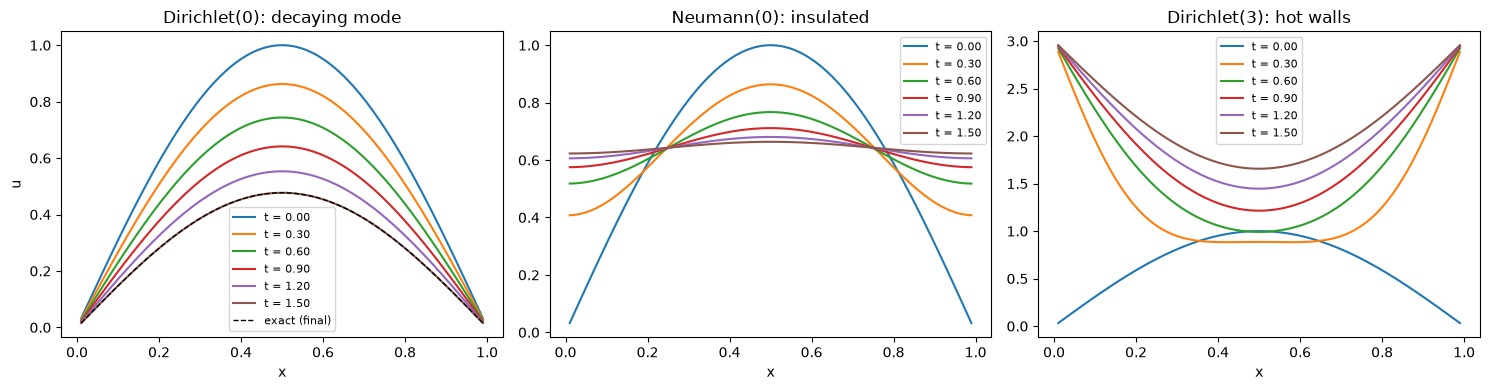

Insulated run: relative change in total heat = 3.73e-14


In [13]:
alpha, dt, steps = 0.05, 1e-3, 1500
grid = Grid(96, 1, lx=1.0)
x = grid.x
u0 = np.sin(np.pi * x)

runs = {
    "Dirichlet(0): decaying mode": Dirichlet(0.0),
    "Neumann(0): insulated": Neumann(0.0),
    "Dirichlet(3): hot walls": Dirichlet(3.0),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
for ax, (label, bc) in zip(axes, runs.items()):
    pde = PDE(grid, [DiffusionTerm(alpha)], bc, time_order=1)
    times, hist = pde.integrate(dt=dt, steps=steps, u0=u0, scheme="crank_nicolson",
                                record_every=300)
    for t, u in zip(times, hist):
        ax.plot(x, u, label=f"t = {t:.2f}")
    ax.set_title(label)
    ax.set_xlabel("x")
axes[0].plot(x, np.sin(np.pi * x) * np.exp(-alpha * np.pi**2 * times[-1]),
             "k--", lw=1, label="exact (final)")
axes[0].set_ylabel("u")
for ax in axes:
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# conservation check for the insulated run
pde = PDE(grid, [DiffusionTerm(alpha)], Neumann(0.0), time_order=1)
_, hist = pde.integrate(dt=dt, steps=steps, u0=u0, scheme="crank_nicolson")
print(f"Insulated run: relative change in total heat = "
      f"{abs(hist[-1].sum() - hist[0].sum()) / hist[0].sum():.2e}")

## 4. Periodic advection: upwind vs. central

Advect a Gaussian pulse once around a periodic domain with $u_t = -v\,u_x$. Upwind is robust but
diffusive (the pulse flattens); central differencing preserves amplitude much better on smooth
data. Both conserve $\sum u$ exactly.

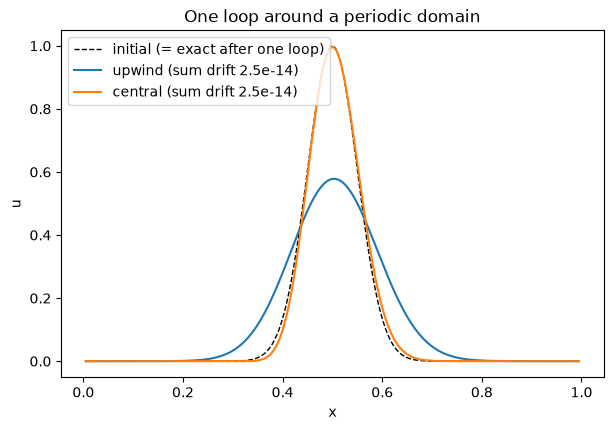

In [14]:
grid = Grid(200, 1, lx=1.0)
x = grid.x
u0 = np.exp(-((x - 0.5) ** 2) / 0.005)
v = 1.0
period = grid.dx * (grid.nx + 1)   # wrap length of the periodic node ring
dt = 2e-4
steps = int(round(period / (v * dt)))  # one full loop

fig, ax = plt.subplots()
ax.plot(x, u0, "k--", lw=1, label="initial (= exact after one loop)")
for scheme in ("upwind", "central"):
    pde = PDE(grid, [AdvectionTerm(v, scheme=scheme)], Periodic(), time_order=1)
    _, hist = pde.integrate(dt=dt, steps=steps, u0=u0, scheme="rk4")
    ax.plot(x, hist[-1], label=f"{scheme} (sum drift {abs(hist[-1].sum()-u0.sum()):.1e})")
ax.set_xlabel("x"); ax.set_ylabel("u"); ax.set_title("One loop around a periodic domain")
ax.legend()
plt.show()

## 5. Wave equation (`time_order=2`)

$u_{tt} = c^2 u_{xx}$ with $u(x,0)=\sin(\pi x)$, $u_t(x,0)=0$ and fixed ends is the standing wave
$u = \sin(\pi x)\cos(\pi c t)$. Integrated with velocity Verlet; snapshots span half a period
(the mode passes through zero and flips sign).

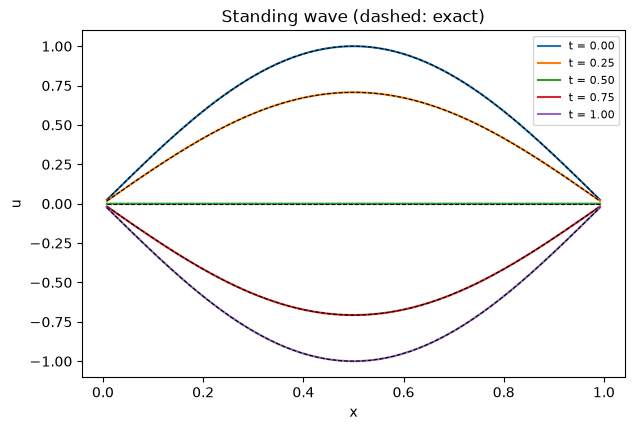

L2 error at t = 1.00: 2.400e-08


In [15]:
grid = Grid(128, 1, lx=1.0)
x = grid.x
c = 1.0
dt = 5e-4
T_half = 1.0 / c                        # half period of the fundamental mode
steps = int(round(T_half / dt))

pde = PDE(grid, [DiffusionTerm(c**2)], Dirichlet(0.0), time_order=2)
times, hist = pde.integrate(dt=dt, steps=steps, u0=np.sin(np.pi * x), record_every=steps // 4)

fig, ax = plt.subplots()
for t, u in zip(times, hist):
    ax.plot(x, u, label=f"t = {t:.2f}")
    ax.plot(x, np.sin(np.pi * x) * np.cos(np.pi * c * t), "k--", lw=0.8)
ax.set_xlabel("x"); ax.set_ylabel("u")
ax.set_title("Standing wave (dashed: exact)")
ax.legend(fontsize=8)
plt.show()

err = np.linalg.norm(hist[-1] - np.sin(np.pi * x) * np.cos(np.pi * c * times[-1]))
print(f"L2 error at t = {times[-1]:.2f}: {err:.3e}")

## 6. Nonlinear reaction: Fisher–KPP front

$u_t = D\,u_{xx} + r\,u(1-u)$ mixes a linear `DiffusionTerm` with a nonlinear `FunctionTerm`.
A small seed grows to the carrying capacity $u=1$ and spreads as a traveling front with asymptotic
speed $2\sqrt{rD}$. Nonlinear terms are integrated explicitly (RK4).

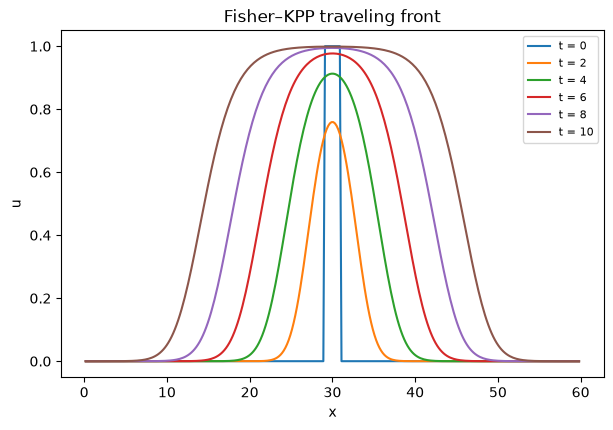

Measured front speed ~ 1.79   (theory: 2*sqrt(r*D) = 2.00)
max(u) = 0.9988  (bounded by carrying capacity 1)


In [16]:
D, r = 1.0, 1.0
grid = Grid(300, 1, lx=60.0)
x = grid.x
u0 = np.where(np.abs(x - 30.0) < 1.0, 1.0, 0.0)

pde = PDE(grid, [DiffusionTerm(D), FunctionTerm(lambda u, X, Y: r * u * (1.0 - u))],
          Dirichlet(0.0), time_order=1)
dt = 5e-3
times, hist = pde.integrate(dt=dt, steps=2000, u0=u0, scheme="rk4", record_every=400)

fig, ax = plt.subplots()
for t, u in zip(times, hist):
    ax.plot(x, u, label=f"t = {t:.0f}")
ax.set_xlabel("x"); ax.set_ylabel("u"); ax.set_title("Fisher–KPP traveling front")
ax.legend(fontsize=8)
plt.show()

# estimate the front speed from the last two snapshots (front = u crosses 0.5)
front = [x[np.argmax(h > 0.5)] for h in (hist[-2], hist[-1])]
speed = abs(front[1] - front[0]) / (times[-1] - times[-2])
print(f"Measured front speed ~ {speed:.2f}   (theory: 2*sqrt(r*D) = {2*np.sqrt(r*D):.2f})")
print(f"max(u) = {hist[-1].max():.4f}  (bounded by carrying capacity 1)")

## 7. 2D advection–diffusion

$u_t = \alpha \nabla^2 u - \mathbf{v}\cdot\nabla u$ transports a Gaussian blob diagonally while
it spreads. Multiple linear terms assemble into a single operator, integrated implicitly
(Crank–Nicolson) with a time step far above the explicit stability limit.

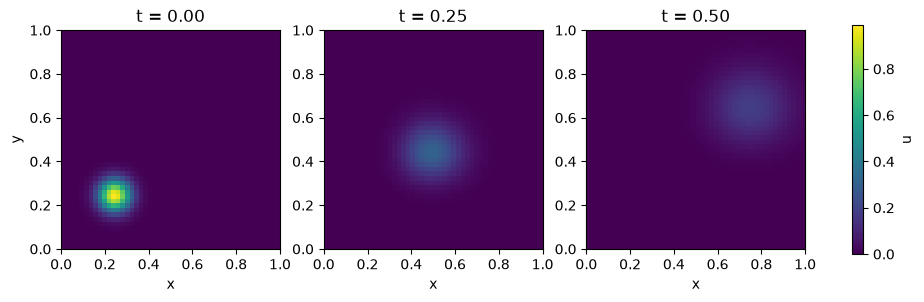

In [17]:
grid = Grid(48, 48, lx=1.0, ly=1.0)
X, Y = grid.mesh()
u0 = np.exp(-((X - 0.25)**2 + (Y - 0.25)**2) / 0.005)

pde = PDE(grid, [DiffusionTerm(2e-3), AdvectionTerm((1.0, 0.8), scheme="upwind")],
          Dirichlet(0.0), time_order=1)
times, hist = pde.integrate(dt=2e-3, steps=250, u0=u0, scheme="crank_nicolson",
                            record_every=125)

fig, axes = plt.subplots(1, len(hist), figsize=(4 * len(hist), 3.5))
for ax, t, u in zip(axes, times, hist):
    im = ax.imshow(u.T, origin="lower", extent=[0, 1, 0, 1], vmin=0, vmax=u0.max(),
                   cmap="viridis")
    ax.set_title(f"t = {t:.2f}")
    ax.set_xlabel("x")
axes[0].set_ylabel("y")
fig.colorbar(im, ax=axes, label="u", shrink=0.85)
plt.show()

## 8. Animation helper

`animated_plot` (from `finite_differences.utils`) animates a solution history. Here: the heat
equation relaxing an off-center pulse under insulated (Neumann) boundaries — it flattens to the
mean instead of draining to zero.

In [18]:
from IPython.display import HTML

grid = Grid(120, 1, lx=1.0)
x = grid.x
u0 = np.exp(-((x - 0.3) ** 2) / 0.004)

pde = PDE(grid, [DiffusionTerm(0.02)], Neumann(0.0), time_order=1)
_, hist = pde.integrate(dt=2e-3, steps=1200, u0=u0, scheme="crank_nicolson", record_every=30)

anim, fig = animated_plot(hist, dimension="1D", title="Insulated diffusion",
                          xlabel="x", ylabel="u", interval_ms=80, extent=[0, 1])
plt.close(fig)  # only show the animation, not the static figure
HTML(anim.to_jshtml())

## 9. Source-driven heating (2D, animated)

A plate with two localized heaters: $u_t = lpha
abla^2 u + s(x,y)$ with cold ($u=0$) edges.
The `SourceTerm` drives the transient toward the balance between heater input and boundary loss.
Because the same terms describe both problems, the `time_order=0` steady solve gives exactly the
state the animation converges to.

In [19]:
from IPython.display import HTML

grid = Grid(40, 40, lx=1.0, ly=1.0)
X, Y = grid.mesh()

def heaters(X, Y):
    return (6.0 * np.exp(-((X - 0.3)**2 + (Y - 0.3)**2) / 0.01)
            + 4.0 * np.exp(-((X - 0.7)**2 + (Y - 0.65)**2) / 0.006))

alpha = 0.1
terms = [DiffusionTerm(alpha), SourceTerm(heaters)]

# transient: start cold and watch the plate heat up
pde = PDE(grid, terms, Dirichlet(0.0), time_order=1)
times, hist = pde.integrate(dt=1e-2, steps=250, u0=np.zeros((grid.nx, grid.ny)),
                            scheme="crank_nicolson", record_every=10)

# the same terms with time_order=0 give the steady state the transient approaches
steady = PDE(grid, terms, Dirichlet(0.0), time_order=0).solve_steady()
gap = np.linalg.norm(hist[-1] - steady) / np.linalg.norm(steady)
print(f"relative distance to the steady state at t = {times[-1]:.1f}: {gap:.1e}")

anim, fig = animated_plot(hist, dimension="2D", title="Heated plate",
                          xlabel="x", ylabel="y", cbarlabel="u",
                          interval_ms=100, extent=[0, 1, 0, 1])
plt.close(fig)
HTML(anim.to_jshtml())

relative distance to the steady state at t = 2.5: 6.7e-03


---
### Summary

| Feature | Where |
|---|---|
| Steady solve (`time_order=0`) | Poisson, Laplace |
| Implicit MOL (`crank_nicolson`) | heat, 2D advection–diffusion |
| Explicit MOL (`rk4`) | advection, Fisher–KPP |
| Second-order time (`time_order=2`) | wave |
| Nonlinear terms (`FunctionTerm`) | Fisher–KPP |
| Source terms (`SourceTerm`) | Poisson, heated plate |
| BCs: `Dirichlet`, `DirichletBox`, `Neumann`, `Periodic` | throughout |